In [1]:
import numpy as np
from scripts.train_vbe_kfold import train_vbe
import torch
import matplotlib.pyplot as plt
from torch import Tensor

In [2]:
_, params_co = np.load("data/coupled_oscillator.npz").values()
dmat_co = torch.tensor(np.load("data/co_dmat.npz")["dmat"], dtype=torch.float32)
dmat_co /= dmat_co.max()
dmat_co_sqr = dmat_co.square()
vbe_co = train_vbe(dmat_co_sqr, "coupled oscillator", lr=4e-3, epochs=200)

100%|██████████| 200/200 [02:25<00:00,  1.38it/s]


In [3]:
traj_qho, params_qho = np.load("data/quantum_ho.npz").values()
dmat_qho = torch.tensor(np.load("data/qho_dmat.npz")["dmat"], dtype=torch.float32)
dmat_qho[dmat_qho.isnan()] = dmat_qho.nanmean()
dmat_qho /= dmat_qho.max()
dmat_qho_sqr = dmat_qho.square()
vbe_qho = train_vbe(dmat_qho_sqr, "quantum harmonic oscillator", epochs=200)

100%|██████████| 200/200 [02:27<00:00,  1.36it/s]


In [4]:
def plot_relevance(relevance: Tensor, system: str, label):
    plt.bar(range(len(relevance)), relevance)
    plt.xlabel("Latent coordinate index")
    plt.ylabel("Relevance score")
    plt.yscale("log")
    plt.title(f"({label}) Components' relevance score\n{system}")


relevance_co = sorted(vbe_co.relevance_score(), reverse=True)
embedding_co = vbe_co.embed(dmat_co_sqr.to(vbe_co.device))

relevance_qho = sorted(vbe_qho.relevance_score(), reverse=True)
embedding_qho = vbe_qho.embed(dmat_qho_sqr.to(vbe_qho.device))

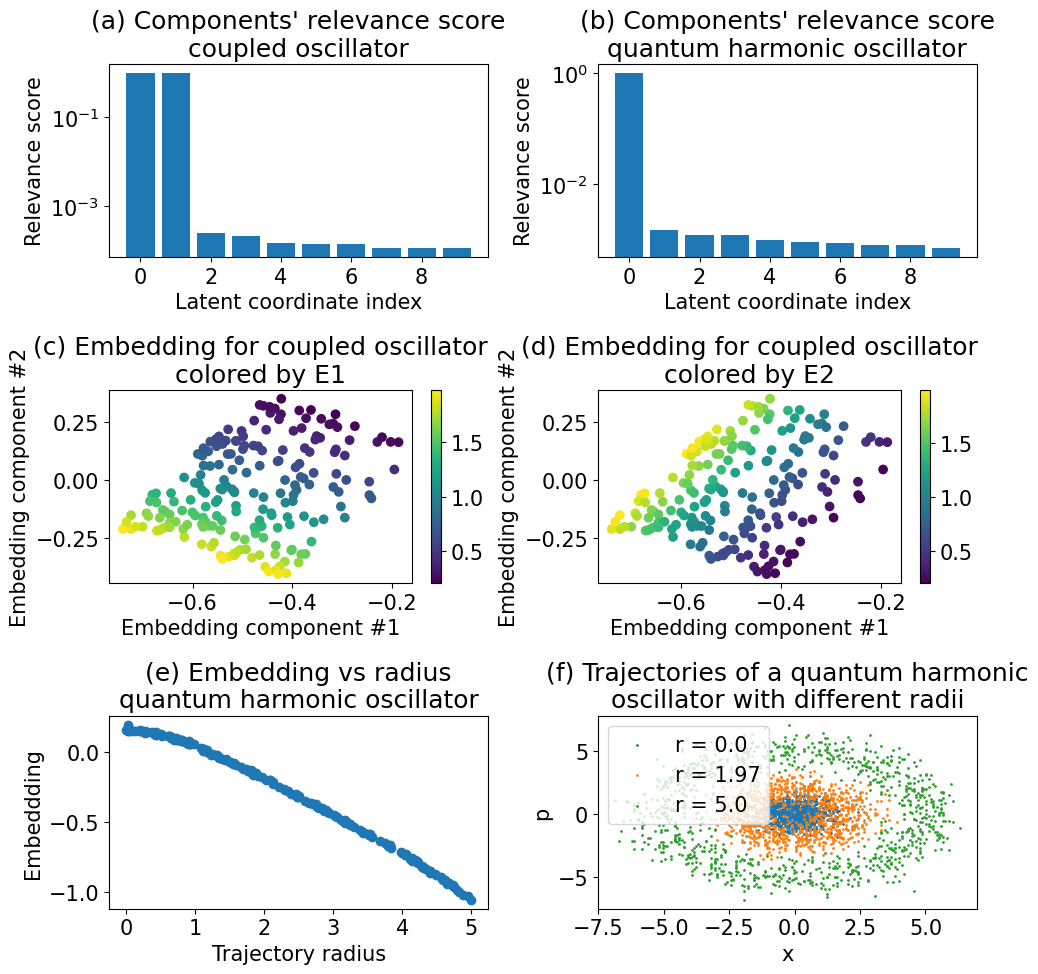

In [6]:
plt.rcParams["font.size"] = 15
plt.figure(figsize=(10, 10))


plt.subplot(3, 2, 1)
plot_relevance(relevance_co[:10], "coupled oscillator", "a")


plt.subplot(3, 2, 2)
plot_relevance(relevance_qho[:10], "quantum harmonic oscillator", "b")


for i, param in enumerate(params_co.T, 1):
    plt.subplot(3, 2, i + 2)
    plt.scatter(*embedding_co.T, c=param)
    plt.xlabel("Embedding component #1")
    plt.ylabel("Embedding component #2")
    plt.title(f"({'c' if i == 1 else 'd'}) Embedding for coupled oscillator\ncolored by E{i}")
    plt.colorbar()


plt.subplot(3, 2, 5)
plt.scatter(params_qho[:, 0], embedding_qho[:, 0])
plt.xlabel("Trajectory radius")
plt.ylabel("Embeddding")
plt.title("(e) Embedding vs radius\nquantum harmonic oscillator")

plt.subplot(3, 2, 6)
idx = np.argsort(params_qho[:, 0])[(np.arange(3) * (len(params_qho) - 1) / 2).astype(int)]
for i in idx:
    plt.scatter(*traj_qho[i].T, label=f"r = {round(params_qho[i, 0], 2)}", s=1)
plt.legend()
plt.xlabel("x")
plt.ylabel("p")
plt.title("(f) Trajectories of a quantum harmonic\noscillator with different radii")


plt.tight_layout()
plt.savefig("physical_systems_graphs.pdf")
plt.show()